In [1]:
import numpy as np
import healpy as hp
import pysm3 as sm

import matplotlib as mpl
import matplotlib.pyplot as plt

import cmasher as cmr
import seaborn as sns

import sys
sys.path.append('../')

from src.utils import pretty_axes, modify_rc, w_object, patch_creation
modify_rc()
modify_rc()
from src import synthesize



In [2]:
NSIDE = 512
LMAX = 3*NSIDE - 1

ells = np.arange(LMAX+1)

sky6 = sm.Sky(nside=NSIDE, preset_strings=['s6'])

/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi


generating monofractal field


/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  (np.asarray(cl, dtype=np.float64) if cl is not None else None)
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1363: ComplexWarning: Casting complex values to real discards the imaginary part
  cls_list = [np.asarray(cls, dtype=np.float64)]


In [3]:

cl_tt = sky6.components[0].small_scale_cl[0][:LMAX+1].value
cl_tt[cl_tt == 0.] = 1e-15
cl_ee = sky6.components[0].small_scale_cl[1][:LMAX+1].value
cl_ee[cl_ee == 0.] = 1e-15
cl_bb = sky6.components[0].small_scale_cl[2][:LMAX+1].value
cl_bb[cl_bb == 0.] = 1e-15
cl_te = sky6.components[0].small_scale_cl[3][:LMAX+1].value
cl_te[cl_te == 0.] = 1e-15

t_delta_params = {
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':5.0,
    'lambda':0.25,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
}
e_delta_params = {
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':5.0,
    'lambda':0.25,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
}
b_delta_params = {
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':5.0,
    'lambda':0.25,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
}

i_delta, q_delta, u_delta = synthesize.make_iqu(
    LMAX, NSIDE, t_delta_params, e_delta_params, b_delta_params, cl_tt, cl_ee, cl_bb, cl_te)
t_delta, e_delta, b_delta = hp.alm2map(hp.map2alm([i_delta, q_delta, u_delta], pol=True), NSIDE, pol=False)


Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.225

In [ ]:
from src.structure_function import sph_structure_function

data = t_delta

MIN_LAG = np.pi/(3*NSIDE - 1)
MAX_LAG = np.pi/3.
NUM_R = 32
NUM_PHI = 32
r_bins = np.exp(np.linspace(np.log(MIN_LAG), np.log(MAX_LAG), NUM_R))
phi_bins = np.linspace(0., np.pi, NUM_PHI)
num_elements = data.size

## Increase num_anchors and chunk_size for better computations
## NOTE: Doing this will require lots of RAM
r, phi, sf2 = sph_structure_function(data - np.nanmean(data), r_bins, phi_bins, num_anchors=500, chunk_size=100, powers=[2,3,4,5,6,7])
print(np.shape(r), np.shape(phi), np.shape(sf2))


Generating KD Tree
Processing 500 anchors in chunks of 100
Chunk:  0
Chunk:  100
Chunk:  200
Chunk:  300
Chunk:  400
(32,) (32,) ()


/home/mark.bishop/Documents/pysm_project/small_scale_synch/examples/../src/structure_function.py:151: RuntimeWarning: invalid value encountered in divide
  sf_sum[p] = sf_sum[p]/counts


<>:12: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:12: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/tmp/ipykernel_69708/42397710.py:12: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  cbar_ax.set_xlabel('$S^{(2)}(r,\phi)$')


[-3 -2 -1  0]


(-3.0, 0.0)

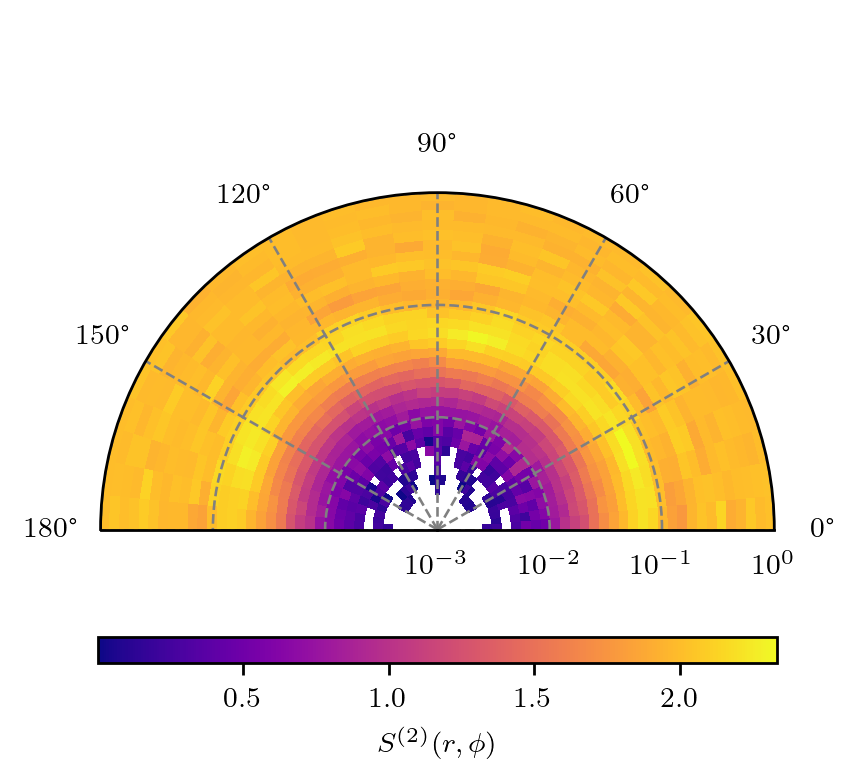

In [5]:
# Setup figure
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(3.5, 3.5))

r_log = np.log10(r)

mesh = ax.pcolormesh(phi, r_log, sf2[2]/np.nanvar(data), cmap='plasma', shading='auto')
ax.grid(linestyle='--', color='gray', linewidth=0.75)

cbar_ax = fig.add_axes([0.125, 0.15, 0.775, 0.03])
fig.colorbar(mesh, cax=cbar_ax, orientation='horizontal')
cbar_ax.xaxis.set_ticks_position('bottom')
cbar_ax.set_xlabel('$S^{(2)}(r,\phi)$')

# plt.colorbar(mesh, ax=ax, orientation='horizontal', pad=0.15, label='$S^{(2)}(r,\phi)$')

# Restrict the polar plot axes to a hemisphere
ax.set_thetamin(0.)
ax.set_thetamax(180.)

start_pow = int(np.floor(np.log10(MIN_LAG)))
end_pow = 0#int(np.ceil(np.log10(MAX_LAG)))
powers = np.arange(start_pow, end_pow+1)
print(powers)
ax.set_rticks(powers, [f'$10^{{{p}}}$' for p in powers])
ax.set_rlim(start_pow, end_pow)
